# Painter Classification with PyTorch

This notebook presents a complete training and evaluation pipeline for fine-tuning a ResNet50 model on a 50-class painter classification task using the [Best Artworks of All Time](https://www.kaggle.com/datasets/ikarus777/best-artworks-of-all-time) Kaggle dataset.<br>Credit to [Icaro](https://www.kaggle.com/ikarus777) for sharing this excellent dataset!<br>The dataset contains 8,446 paintings from 50 artists, with class imbalance (ranging from ~25 to 800+ paintings per artist).

This notebook uses PyTorch.<br>
I also created a version using the FastAI library here: **[FastAI version](https://www.kaggle.com/code/amarietiberiu/fast-ai-painter-classification)**.<br>
For exploratory data analysis on this dataset check out this notebook: **[EDA](https://www.kaggle.com/code/amarietiberiu/eda-painter-classification)**

We achieve **~85% accuracy** and **~0.85 macro-average F1** on the validation set.

**Contents:**
1. Building the Dataset class, image transforms, DataLoader, and tools for handling class imbalance
2. Fine-Tuning Phase 1: Training only the new classification head (3 epochs) as a warmup
3. Fine-Tuning Phase 2: Unfreezing deeper layers and fine-tuning with discriminative learning rates (25 epochs)
4. Results analysis: confusion matrix, top losses, per-class metrics
5. Loading the best checkpoint and running inference

In [1]:
# Ensure we have the data available
import kagglehub
import os

path = '/kaggle/input/datasets/ikarus777/best-artworks-of-all-time'
if not os.environ.get('KAGGLE_KERNEL_RUN_TYPE', ''):
    path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
print(f"Path to dataset files: {path}") 

Path to dataset files: /kaggle/input/datasets/ikarus777/best-artworks-of-all-time


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from collections import Counter
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import numpy as np

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## Preparing the Dataset and the DataLoaders

We start by creating a `PaintersDataset` class that loads images from disk, handles folder-naming issues (encoding artifacts for "Albrecht Dürer"), applies transforms, and returns `(image_tensor, label)` pairs. We instantiate it twice (once with training augmentations and once with validation transforms), then use `Subset` to create the actual train/val splits.

In [3]:
import unicodedata
class PaintersDataset(Dataset):
    """ PyTorch Dataset for the 'Best Artworks of All Time' Kaggle dataset 
        Args:
        root: Path to the Kaggle dataset root. Images are loaded from
            root/images/images/<Artist_Name>/*.jpg
    """

    def __init__(self, root, transform=None):
        root = Path(root)
        self.transform = transform
        data_dir = root / 'images' / 'images'

        if not data_dir.exists():
            raise FileNotFoundError(
                f"Could not find {data_dir}. "
                f"Pass the dataset root — images are expected at root/images/images/<Artist_Name>/*.jpg"
            )
        self.class_names = []
        self.image_paths = []
        self.labels = []
        
        # Mapping for folders whose names got mangled (encoding issues).
        LABEL_ALIASES = {
            "Albrecht_DuΓòá├¬rer": "Albrecht_Dürer",
            "Albrecht_Du╠êrer": "Albrecht_Dürer"
        }
        for folder in sorted(data_dir.iterdir()):
            if not folder.is_dir():
                continue
            label = self._normalize(LABEL_ALIASES.get(folder.name, folder.name))
            if label in self.class_names:
                continue # Skip duplicate folders (e.g. for "Albrecht_Dürer")
            self.class_names.append(label)
            for img_path in folder.glob("*.jpg"):
                self.image_paths.append(img_path)
                self.labels.append(label)
                
        self.class_to_idx = {cls:idx for idx, cls in enumerate(self.class_names)}
        self.labels = [self.class_to_idx[label] for label in self.labels]
        self.idx_to_class = {idx:cls for cls, idx in self.class_to_idx.items()}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
          img = self.transform(img)
        return img, self.labels[idx]

    def _normalize(self, s: str) -> str:
        return unicodedata.normalize('NFC', s)

We define separate image transforms for training and validation.

The training transforms include random cropping (to 448px), flipping, rotation, color jitter, and random erasing. These act as regularization by forcing the model to learn from varied views of each painting rather than memorizing exact pixel patterns.

The validation transforms only resize to 540px and center-crop to 512px, without any random augmentation. This keeps the pipeline deterministic, simulating real-world inference conditions. The validation pipeline uses a larger crop-size than training (512px vs 448px) to give the model more spatial context at test time, which tends to improve accuracy.

Both pipelines use ImageNet normalization statistics (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) because our ResNet50 backbone was pre-trained on ImageNet with these values. Using different normalization would lead to a significant drop in performance. This is because the pixel values would fall outside the numerical range the pre-trained filters expect, causing them to struggle to extract meaningful features.

In [4]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(448, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.3)
])

val_transforms = transforms.Compose([
    transforms.Resize(540),
    transforms.CenterCrop(512),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )    
])

In [5]:
from sklearn.model_selection import train_test_split

train = PaintersDataset(path, train_transforms)
valid = PaintersDataset(path, val_transforms)
labels = train.labels
class_names = train.class_names
n_classes = len(class_names)
class_to_idx = train.class_to_idx
idx_to_class = train.idx_to_class
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device set to: {device}")

# We split the data into train (85%) and validation (15%) using stratified sampling.
indices = list(range(len(train)))
train_idx, valid_idx = train_test_split(
    indices,
    stratify=labels,
    test_size=0.15,
    random_state=42
)
train_dataset = Subset(train, train_idx)
valid_dataset = Subset(valid, valid_idx)
print(f"Number of train images: {len(train_dataset)}")
print(f"Number of validation images: {len(valid_dataset)}")

Device set to: cuda
Number of train images: 7179
Number of validation images: 1267


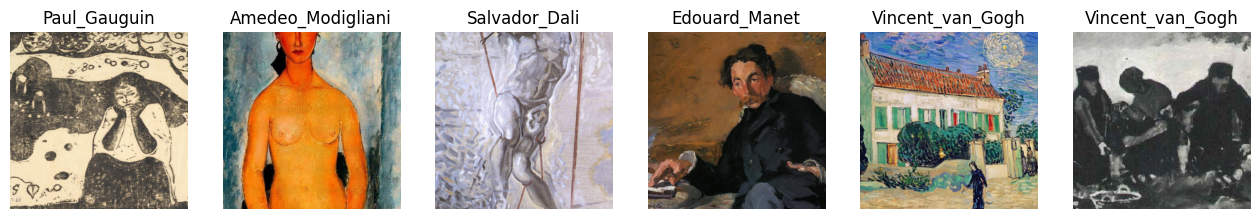

In [6]:
def show_batch(dataset, idx_to_class, n=6, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """ Function for displaying a random batch of images from dataset"""
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    plt.figure(figsize=(16, 8))
    for i in range(n):
        img, label = random.choice(dataset)
        img = img * std + mean
        img = img.permute(1, 2, 0)
        img = img.clip(0, 1)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(idx_to_class[label])

show_batch(valid_dataset, idx_to_class)

Because the dataset is heavily imbalanced, a standard random sampler would under-represent minority classes during training. `WeightedRandomSampler` assigns each sample a weight inversely proportional to its class frequency (linear inverse), so minority-class images are drawn more often. This effectively gives the model a roughly balanced view of all 50 classes each epoch.

We create PyTorch DataLoaders that serve batches of 32 images. `pin_memory=True` allocates the CPU tensors in page-locked memory, which speeds up the CPU -> GPU data transfer.

In [7]:
from torch.utils.data import WeightedRandomSampler
from collections import Counter

targets = [labels[idx] for idx in train_idx]
class_counts = Counter(targets)
total = len(targets)

# Linear inverse: aggressive oversampling so minority classes appear ~ equally often
class_weights = {cls: total / count for cls, count in class_counts.items()}
sample_weights = [class_weights[target] for target in targets]

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=train_sampler,
    pin_memory=True,
    num_workers=4
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True,
    num_workers=4
)

Standard training loop for one epoch: iterate over batches, zero gradients, run the forward pass, compute the loss, backpropagate, and update weights.

In [9]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    train_losses = []
    model.train()
    for batch, targets in tqdm(dataloader):
        batch = batch.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        preds = model(batch)
        loss = loss_fn(preds, targets)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
    return train_losses

During validation we run the model in eval mode with gradients disabled (`with torch.no_grad()`) and compute the confusion matrix and the top-loss samples. The top losses help us inspect which specific images the model struggles with most, which is useful for debugging.

In [10]:
def validate(dataloader, model, loss_fn, loss_fn_sample):
    val_losses = []
    cm = torch.zeros((n_classes, n_classes), dtype=torch.long, device=device)
    model.eval()
    all_metrics = []
    all_images = []
    
    with torch.no_grad():
        for batch, targets in tqdm(dataloader):
            batch = batch.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            
            outputs = model(batch)
            loss = loss_fn(outputs, targets)
            val_losses.append(loss.item())
            predictions = torch.softmax(outputs, dim=-1).argmax(dim=-1)

            # Compute confusion matrix
            indices = targets * n_classes + predictions
            cm += torch.bincount(indices, minlength=n_classes ** 2).reshape(n_classes, n_classes)
            
            # Compute top k losses
            loss_samples = loss_fn_sample(outputs, targets)
            k = 6
            top_k_idx = torch.argsort(loss_samples, descending=True)[:k]
            for i in top_k_idx:
                all_metrics.append((predictions[i].item(), targets[i].item(), loss_samples[i].item()))
                all_images.append(batch[i].cpu())

        # global top-k
        all_metrics_sorted = sorted(enumerate(all_metrics), key=lambda x: x[1][2], reverse=True)[:6]
        top_indices = [i for i, _ in all_metrics_sorted]
        top_losses = {
            'preds':   [idx_to_class[all_metrics[i][0]] for i in top_indices],
            'actuals': [idx_to_class[all_metrics[i][1]] for i in top_indices],
            'losses':  [all_metrics[i][2] for i in top_indices],
            'images':  torch.stack([all_images[i] for i in top_indices]),
        }
        val_loss = sum(val_losses) / len(val_losses)
    return val_loss, cm, top_losses

In [11]:
def get_metrics_from_cm(cm):
    """ Function for extracting the Precision, Recall and F1 score from confusion matrix """
    metrics = []
    eps = 1e-8
    for i in range(cm.shape[0]):
        TP = cm[i, i].item()
        FP = cm[:, i].sum().item() - TP
        FN = cm[i].sum().item() - TP
        Precision = TP / (TP + FP + eps)
        Recall = TP / (TP + FN + eps)
        F1 = 2 * Precision * Recall / (Precision + Recall + eps)
        metrics.append([F1, Precision, Recall])
    return metrics

In [12]:
def log_per_class_metrics(cm):
    """ Function to display metrics per class, sorted by F1, using confusion matrix"""
    metrics = get_metrics_from_cm(cm)
    order = torch.argsort(torch.tensor(metrics)[:, 0])
    for idx in order:
        F1, Precision, Recall = metrics[idx]
        print(f"{idx_to_class[idx.item()]}: F1={F1:.4f}, Precision={Precision:.4f}, Recall={Recall:.4f}")

In [13]:
def plot_top_confusions(cm, k=10):
    pairs = {}
    ln = cm.shape[0]
    for i in range(ln - 1):
        for j in range(i + 1, ln):
            pairs[(i, j)] = cm[i, j].item() + cm[j, i].item()
    pairs = sorted(pairs.items(), key=lambda x: x[1], reverse=True)[:k]

    labels = [f"{idx_to_class[i]} ↔ {idx_to_class[j]}" for (i, j), _ in pairs]
    counts = [c for _, c in pairs]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(labels[::-1], counts[::-1])
    ax.set_xlabel('Misclassifications')
    ax.set_title(f'Top {k} Confused Class Pairs')
    fig.tight_layout()
    plt.show()

In [14]:
def plot_top_losses(top_losses):
    """ Function to plot top losses"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    preds = top_losses['preds']
    actuals = top_losses['actuals']
    losses = top_losses['losses']
    images = top_losses['images']
    mean=torch.tensor([0.485, 0.456, 0.406])
    std=torch.tensor([0.229, 0.224, 0.225])
    
    for idx, ax in enumerate(axes.flat):
        img = images[idx].permute(1, 2, 0).cpu().numpy()
        img = img * std.numpy() + mean.numpy()
        img = img.clip(0, 1)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(
            f"Pred: {preds[idx]} | Actual: {actuals[idx]} | Loss: {losses[idx]:.4f}",
            fontsize=10
        )
    plt.tight_layout()
    plt.show()


In [15]:
def ema_smoothing(values, beta=0.9):
    """ Function for computing the Exponential Moving Average of the training graph for better visualisation """
    results = []
    v = 0
    for t, val in enumerate(values, start=1):
        v = beta * v + (1 - beta) * val
        results.append(v / (1 - beta**t))
    return results

In [16]:
def plot_performance(train_losses, valid_losses, F1s, accs):
    """Function for plotting the performance graphs"""
    train_losses_ema = ema_smoothing(train_losses)
    train_idx = list(range(len(train_losses_ema)))
    valid_idx = list(range(len(valid_losses)))
    
    fig, ax = plt.subplots(2, 2)
    ax[0, 0].plot(train_idx, train_losses, alpha=0.3, label='raw')
    ax[0, 0].plot(train_idx, train_losses_ema, color='red', label='EMA')
    ax[0, 0].set_title('Train loss')
    ax[0, 1].plot(valid_idx, valid_losses)
    ax[0, 1].set_title('Valid loss')
    ax[1, 0].plot(valid_idx, F1s)
    ax[1, 0].set_title('Valid F1 scores')
    ax[1, 1].plot(valid_idx, accs)
    ax[1, 1].set_title('Valid Accuracy')
    fig.tight_layout()
    plt.show()
    

The main training loop runs for a given number of epochs (3 for phase 1 and 25 for phase 2). We use cosine annealing to smoothly decay the learning rate over the course of training. The best model checkpoint (by macro F1) is saved to disk.

In [17]:
def train_stage(STAGE_EPOCHS, train_dataloader, valid_dataloader, model, optimizer, loss_fn, loss_fn_sample, scheduler=None, save=None):
    all_train_losses, all_valid_losses, F1s, accs = [], [], [], []
    for epoch in range(STAGE_EPOCHS):
        train_losses = train_one_epoch(train_dataloader, model, loss_fn, optimizer)
        valid_loss, cm, top_losses = validate(valid_dataloader, model, loss_fn, loss_fn_sample)
        if scheduler: scheduler.step()
        
        f1s = [F1 for (F1, _, _) in get_metrics_from_cm(cm)]
        counts_per_class = cm.sum(dim=1).item()
        macro_avg_F1 = sum(f1s) / len(f1s)
        weighted_F1 =  sum(f1s * counts_per_class) / cm.sum().item()
        train_loss = sum(train_losses) / len(train_losses) 
        valid_acc = (cm.diag().sum() / cm.sum()).item() 
        print(f"Epoch {epoch} - Train loss: {train_loss:.4f} | Valid loss: {valid_loss:.4f} | Valid Accuracy: {valid_acc:.4f} | Macro-Avg F1: {macro_avg_F1:.4f} | Weighted F1: {weighted_F1:.4f}")    

        if save and macro_avg_F1 > save['mx']:
            save['mx'] = macro_avg_F1
            save_path = f"best_model.pt"
            save['path'] = save_path
            torch.save(model.state_dict(), save_path)
            print(f"Saved model on epoch: {epoch}, with F1: {macro_avg_F1}, at: {save_path}")
        
        if epoch == STAGE_EPOCHS - 1:
            log_per_class_metrics(cm)
            plot_top_confusions(cm, 10)
            plot_top_losses(top_losses)
    
        all_train_losses.extend(train_losses)
        all_valid_losses.append(valid_loss)
        F1s.append(macro_avg_F1)
        accs.append(valid_acc)
    plot_performance(all_train_losses, all_valid_losses, F1s, accs)

## Fine-Tuning Phase 1: Train only the new classification head

We load a ResNet50 with ImageNet-pretrained weights and replace the final fully-connected layer with a new two-layer head (2048 input -> 512 hidden -> 50 output). We also freeze all backbone parameters.

This warmup phase, with only the head being trainable, lets the head converge to reasonable outputs before we modify the backbone. Without this step, poorly directed gradients from the untrained head would propagate back and destabilize the pretrained features.

In [18]:
from torchvision.models import resnet50, ResNet50_Weights

STAGE_ONE_EPOCHS = 3
STAGE_TWO_EPOCHS = 25

model = resnet50(weights = ResNet50_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(512, n_classes)
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s] 


We configure the loss function with two adjustments for class imbalance:

1. **Class weights** (square root of inverse frequency): The loss penalizes errors on rare classes more heavily. After comparing validation F1 scores, square root of inverse frequency produced better results than raw inverse frequency. These loss weights control how much each mistake costs, while the sampler controls how often classes appear.
2. **Label smoothing (0.1)**: Instead of hard 0/1 targets, we use 0.9 for the correct class and distribute uniformly the remaining 0.1 across the other classes. This discourages the model from becoming overconfident.

In [19]:
# penalize minority errors more, but not as extreme as linear (sqrt dampening)
weights = torch.tensor(
    [class_weights[i] ** 0.5 for i in range(n_classes)],
    dtype=torch.float
)
loss_fn = nn.CrossEntropyLoss(weight=weights.to(device), label_smoothing=0.1)
optimizer = torch.optim.AdamW(
    params=model.fc.parameters(), lr=2e-3, weight_decay=0.01
)
loss_fn_sample = nn.CrossEntropyLoss(reduction='none') # Used for extracting top losses per sample

In [20]:
train_stage(STAGE_ONE_EPOCHS, train_loader, valid_loader, model, optimizer, loss_fn, loss_fn_sample)

100%|██████████| 40/40 [00:21<00:00,  1.83it/s]


TypeError: tensor() missing 1 required positional arguments: "data"

## Fine-Tuning Phase 2: Unfreeze layers 3 and 4

For phase 2 we unfreeze `layer3` and `layer4` of the ResNet50 backbone and set up discriminative learning rates:
- **1e-4** for the backbone layers. We use small updates to preserve pretrained features
- **1e-3** for the classification head. We use larger updates since it still needs to adapt and specialize on our task

Cosine annealing decays all learning rates smoothly to 1e-6 over 25 epochs.

In [ ]:
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True
optimizer_full = torch.optim.AdamW([
    {'params': model.layer3.parameters(), 'lr': 1e-4},
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3},
], weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_full, T_max=STAGE_TWO_EPOCHS, eta_min=1e-6
)
save = {
    'mx': 0.75,
    'path': ''
}

In [ ]:
train_stage(STAGE_TWO_EPOCHS, train_loader, valid_loader, model, optimizer_full, loss_fn, loss_fn_sample, scheduler, save)

## Results

Training is complete. The loss curves and metrics show healthy convergence.<br>
The model still confuses artists with similar styles. For example Claude Monet and Alfred Sisley (both Impressionists), or Edgar Degas and Pierre-Auguste Renoir. This is expected: even art historians sometimes debate attributions within the same movement. The top-loss visualizations and most-confused pairs above make these patterns clear. <br><br>
For more exploratory data analysis check out this notebook: [EDA](https://www.kaggle.com/code/amarietiberiu/eda-painter-classification)

## Running inference on the best checkpoint

We can reload the best checkpoint and run inference on a user-uploaded image.

In [ ]:
model = resnet50()
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(512, 50) # 50 artists in the dataset
)
model.load_state_dict(torch.load(save['path'], weights_only=True))
model.eval()
print("Model loaded!")

In [ ]:
import ipywidgets as widgets

uploader = widgets.FileUpload()
uploader

In [ ]:
import io

img = None
if len(uploader.value):
    img = Image.open(io.BytesIO(uploader.value[-1].content.tobytes()))
else:
    img = Image.open(Path('/kaggle/input/datasets/ikarus777/best-artworks-of-all-time/images/images/Leonardo_da_Vinci/Leonardo_da_Vinci_114.jpg'))
img = val_transforms(img).unsqueeze(0)

model.eval()
with torch.no_grad():
    output = model(img)
    prediction = output.softmax(dim=-1).argmax(dim=-1)
    label = idx_to_class[prediction.item()]
    print(f"Prediction: {label}")

#### That's it!
#### Please share your thoughts and feedback in the comments. If you liked the notebook please "upvote" 🔝
#### Check out [https://github.com/Tiberiw](https://github.com/Tiberiw) for other projects I am working on :)